In [1]:
from neuralhydrology.utils.config import Config
from neuralhydrology.utils.DCFE_utils import get_dcfe_params
from neuralhydrology.datautils import utils
from pathlib import Path
import torch
from neuralhydrology.nh_run import start_run

## Format HydroAtlas Basin Attributes

## Simple LSTM for AORC

In [3]:
# by default we assume that you have at least one CUDA-capable NVIDIA GPU
if torch.cuda.is_available():
    print("GPU")
    start_run(config_file=Path("2basin_lstmHourly_AORC.yml"))

# fall back to CPU-onl y mode
else:
    print("CPU")
    start_run(config_file=Path("2basin_lstmHourly_AORC.yml"), gpu=-1)

CPU
2025-08-16 18:49:57,149: Logging to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/testLSTM_AORC_run_1608_184957/output.log initialized.
2025-08-16 18:49:57,150: ### Folder structure created at /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/testLSTM_AORC_run_1608_184957
2025-08-16 18:49:57,151: ### Run configurations for testLSTM_AORC_run
2025-08-16 18:49:57,151: experiment_name: testLSTM_AORC_run
2025-08-16 18:49:57,151: train_basin_file: 2_basin.txt
2025-08-16 18:49:57,152: validation_basin_file: 2_basin.txt
2025-08-16 18:49:57,152: test_basin_file: 2_basin.txt
2025-08-16 18:49:57,152: train_start_date: 1999-10-01 00:00:00
2025-08-16 18:49:57,152: train_end_date: 2005-09-30 00:00:00
2025-08-16 18:49:57,153: validation_start_date: 1985-10-01 00:00:00
2025-08-16

/Users/ziyu/miniconda3/envs/dCFE_env/lib/python3.12/site-packages/neuralhydrology/modelzoo/__init__.py:74: FutureWarning: The `LSTM` class has been renamed to `CustomLSTM`. Support for `LSTM` will we dropped in the future.
  warnings.warn(


# Epoch 1: 100%|██████████| 399/399 [19:51<00:00,  2.99s/it, Loss: 0.2293]   
2025-08-16 19:09:54,754: Epoch 1 average loss: avg_loss: 0.24868, avg_total_loss: 0.24868
# Epoch 2: 100%|██████████| 399/399 [4:09:38<00:00, 37.54s/it, Loss: 0.0629]    
2025-08-16 23:19:32,987: Epoch 2 average loss: avg_loss: 0.12224, avg_total_loss: 0.12224
# Epoch 3: 100%|██████████| 399/399 [4:26:07<00:00, 40.02s/it, Loss: 0.0452]    
2025-08-17 03:45:40,385: Epoch 3 average loss: avg_loss: 0.09238, avg_total_loss: 0.09238
Metrics for 1h are calculated over last 1 elements only. Ignoring 23 predictions per sequence.
# Validation: 100%|██████████| 1/1 [49:38<00:00, 2978.40s/it]
2025-08-17 04:52:26,004: Epoch 3 average validation loss: nan -- Median validation metrics: avg_loss: nan
# Epoch 4: 100%|██████████| 399/399 [2:51:56<00:00, 25.86s/it, Loss: 0.1334]    
2025-08-17 07:44:22,368: Epoch 4 average loss: avg_loss: 0.08031, avg_total_loss: 0.08031
# Epoch 5: 100%|██████████| 399/399 [2:36:16<00:00, 23.5

In [30]:
from neuralhydrology.evaluation import metrics, get_tester
import pandas as pd
from neuralhydrology.utils.config import Config
import matplotlib.pyplot as plt

run_dir = Path("runs/testLSTM_AORC_run_1108_132606")
run_config = Config(run_dir / "config.yml")

# create a tester instance and start evaluation
tester = get_tester(cfg=Config(run_dir / "config.yml"), run_dir=run_dir, period="test", init_model=True)
results = tester.evaluate(save_results=True, metrics=run_config.metrics)

2025-08-11 13:45:53,547: Using the model weights from runs/testLSTM_AORC_run_1108_132606/model_epoch010.pt


/Users/ziyu/miniconda3/envs/dCFE_env/lib/python3.12/site-packages/neuralhydrology/modelzoo/__init__.py:74: FutureWarning: The `LSTM` class has been renamed to `CustomLSTM`. Support for `LSTM` will we dropped in the future.
  warnings.warn(


Metrics for 1h are calculated over last 1 elements only. Ignoring 23 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:44<00:00, 22.16s/it]
2025-08-11 13:46:37,878: Stored metrics at runs/testLSTM_AORC_run_1108_132606/test/model_epoch010/test_metrics.csv
2025-08-11 13:46:37,886: Stored results at runs/testLSTM_AORC_run_1108_132606/test/model_epoch010/test_results.p


In [20]:
hourly.keys()

KeysView(<xarray.Dataset> Size: 84MB
Dimensions:               (time: 2103000)
Coordinates:
    t                     (time) object 17MB MultiIndex
    date                  (time) datetime64[ns] 17MB 1989-10-01T23:00:00 ... ...
    time_step             (time) int64 17MB -23 -22 -23 -21 -22 ... -1 -2 0 -1 0
  * time                  (time) datetime64[ns] 17MB 1989-10-01 ... 1999-09-3...
Data variables:
    qobs_mm_per_hour_obs  (time) float32 8MB 0.4399 0.4489 ... 0.05241 0.05155
    qobs_mm_per_hour_sim  (time) float32 8MB 0.5455 0.5492 ... 0.08409 0.08121)

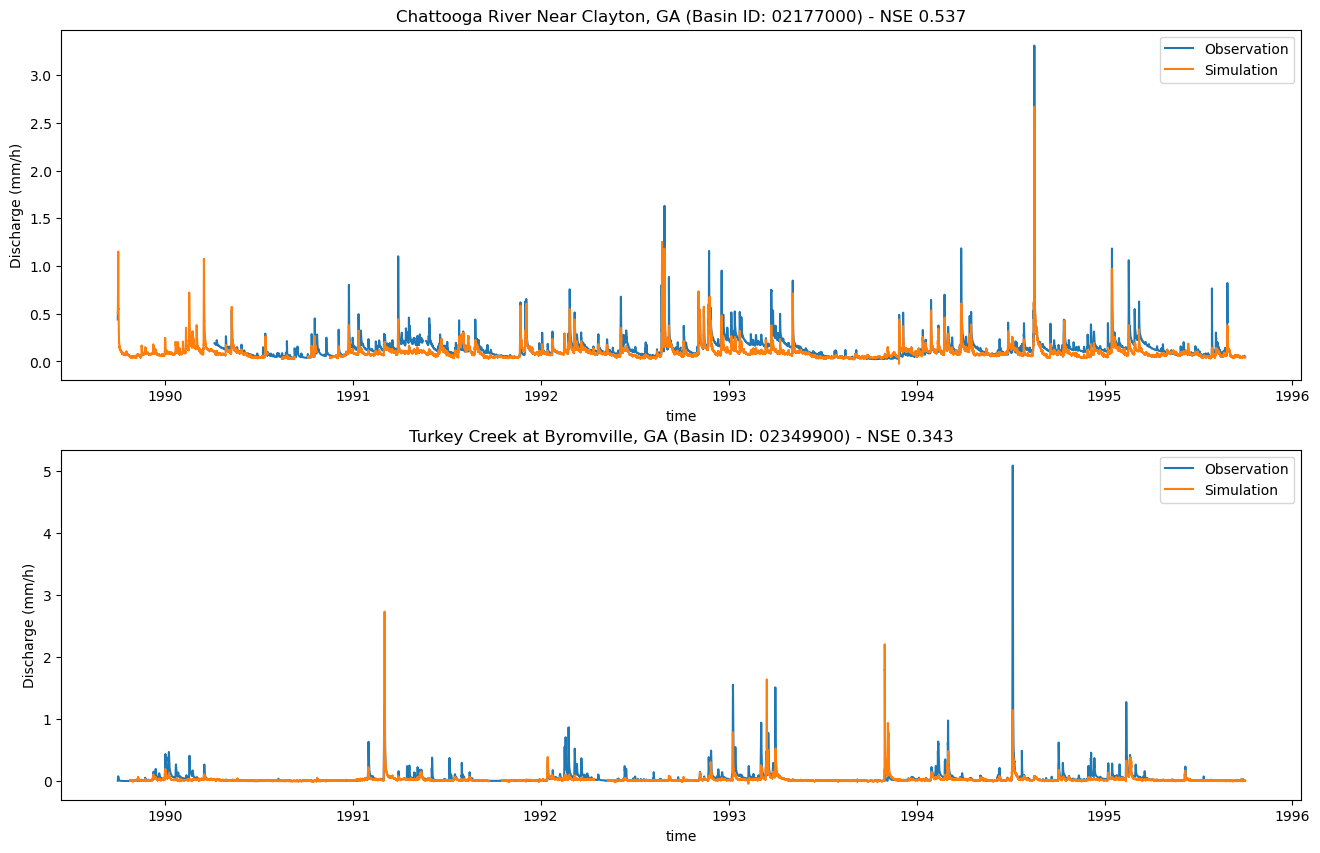

In [31]:
import numpy as np
import matplotlib.pyplot as plt



fig, ax = plt.subplots(2, 1, figsize=(16,10))
# 1) Slice by date (ISO format)
hourly_xr = results["02177000"]["1h"]["xr"].sel(date=slice("1989-10", None))

# 2) Stack 2D (date, time_step) → 1D 't'
hourly = hourly_xr.stack(t=("date", "time_step"))

# 3) Build timedelta and new time coordinate
td = hourly["time_step"].values.astype("timedelta64[h]")
time = hourly["date"].values + td

# 4) Assign and swap dims
hourly = hourly.assign_coords(time=("t", time)).swap_dims({"t": "time"}).sortby("time")

hourly["qobs_mm_per_hour_obs"].plot(ax=ax[0], label="Observation")
hourly["qobs_mm_per_hour_sim"].plot(ax=ax[0], label="Simulation")
ax[0].set_ylabel("Discharge (mm/h)")
ax[0].set_title(f"Chattooga River Near Clayton, GA (Basin ID: 02177000) - NSE {results['02177000']['1h']['NSE']:.3f}")
ax[0].legend()


# 1) Slice by date (ISO format)
hourly_xr = results["02349900"]["1h"]["xr"].sel(date=slice("1989-10", None))

# 2) Stack 2D (date, time_step) → 1D 't'
hourly = hourly_xr.stack(t=("date", "time_step"))

# 3) Build timedelta and new time coordinate
td = hourly["time_step"].values.astype("timedelta64[h]")
time = hourly["date"].values + td

# 4) Assign and swap dims
hourly = hourly.assign_coords(time=("t", time)).swap_dims({"t": "time"}).sortby("time")

hourly["qobs_mm_per_hour_obs"].plot(ax=ax[1], label="Observation")
hourly["qobs_mm_per_hour_sim"].plot(ax=ax[1], label="Simulation")
ax[1].set_ylabel("Discharge (mm/h)")
ax[1].set_title(f"Turkey Creek at Byromville, GA (Basin ID: 02349900) - NSE {results['02349900']['1h']['NSE']:.3f}")
ax[1].legend()

plt.show()


## AORC for NH-dCFE

In [4]:
# Grab config file so we can see if the code works
#config_path = Path('/Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology/neuralhydrology/examples/07-DifferentialCFE-Model/2basinTest_devMultiBasin.yml')
config_path = Path('/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/2basin_AORC.yml')
config = Config(config_path, dev_mode=True)
basins = utils.load_basin_file(getattr(config, "train_basin_file"))

testDF = get_dcfe_params(config)
testDF.loc['02177000']
#testDF.loc['02349900']

depth                                                        tensor(2.)
bb                                                       tensor(1.8747)
satdk                                                    tensor(0.0007)
satpsi                                                   tensor(0.1889)
slop                                                     tensor(0.8340)
smcmax                                                   tensor(0.2987)
wltsmc                                                   tensor(0.0521)
D                                                            tensor(2.)
mult                                                         tensor(1.)
catchment_area_km2                                     tensor(111.1100)
refkdt                                                   tensor(0.8883)
max_gw_storage                                           tensor(0.2016)
expon                                                    tensor(1.8009)
Cgw                                                      tensor(

In [5]:
# by default we assume that you have at least one CUDA-capable NVIDIA GPU
if torch.cuda.is_available():
    print("GPU")
    start_run(config_file=Path("2basin_AORC.yml"))

# fall back to CPU-onl y mode
else:
    print("CPU")
    start_run(config_file=Path("2basin_AORC.yml"), gpu=-1)

CPU
2025-08-18 14:40:49,838: Logging to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/DevMultiBasin_Test_1808_144049/output.log initialized.
2025-08-18 14:40:49,842: ### Folder structure created at /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/DevMultiBasin_Test_1808_144049
2025-08-18 14:40:49,842: ### Run configurations for DevMultiBasin_Test
2025-08-18 14:40:49,844: experiment_name: DevMultiBasin_Test
2025-08-18 14:40:49,844: train_basin_file: 2_basin.txt
2025-08-18 14:40:49,844: validation_basin_file: 2_basin.txt
2025-08-18 14:40:49,844: test_basin_file: 2_basin.txt
2025-08-18 14:40:49,845: train_start_date: 2000-10-01 00:00:00
2025-08-18 14:40:49,845: train_end_date: 2010-09-30 00:00:00
2025-08-18 14:40:49,845: validation_start_date: 1992-09-30 00:00:00
2025-0

In [8]:
Result_xr_1

<xarray.Dataset> Size: 12kB
Dimensions:              (date: 2, time_step: 365)
Coordinates:
  * date                 (date) datetime64[ns] 16B 2000-09-29 2000-09-30
  * time_step            (time_step) int64 3kB -364 -363 -362 -361 ... -2 -1 0
    datetime             (time_step) datetime64[ns] 3kB 1999-10-01 ... 2000-0...
Data variables:
    QObs_mm_per_day_obs  (date, time_step) float32 3kB 1.029 0.8201 ... 0.6195
    QObs_mm_per_day_sim  (date, time_step) float32 3kB nan nan nan ... nan nan

2025-08-18 14:59:24,447: Using the model weights from runs/DevMultiBasin_Test_1808_144049/model_epoch003.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:00<00:00,  3.56it/s]
2025-08-18 14:59:25,013: Stored metrics at runs/DevMultiBasin_Test_1808_144049/test/model_epoch003/test_metrics.csv
2025-08-18 14:59:25,017: Stored results at runs/DevMultiBasin_Test_1808_144049/test/model_epoch003/test_results.p


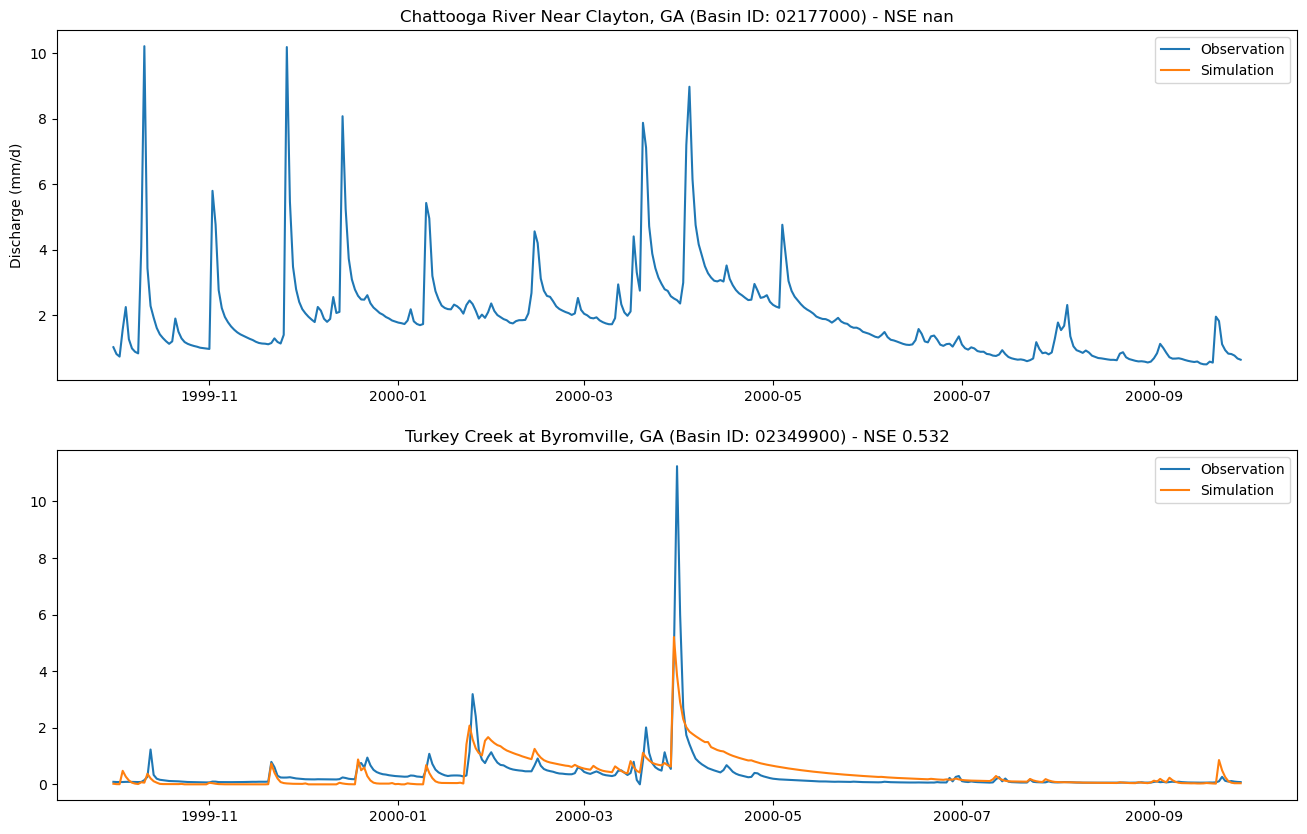

In [7]:
from neuralhydrology.evaluation import metrics, get_tester
import pandas as pd
from neuralhydrology.utils.config import Config
import matplotlib.pyplot as plt

run_dir = Path("runs/DevMultiBasin_Test_1808_144049")
run_config = Config(run_dir / "config.yml")

# create a tester instance and start evaluation
tester = get_tester(cfg=Config(run_dir / "config.yml"), run_dir=run_dir, period="test", init_model=True)
results = tester.evaluate(save_results=True, metrics=run_config.metrics)

results.keys()


# Extract a date slice of observations and simulations
Result_xr_1 = results['02177000']['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar date and the 1D array of time_step values
date_scalar_1 = Result_xr_1.coords['date'][0].values  # Extract as a NumPy scalar
time_step_values_1 = Result_xr_1.coords['time_step'].values  # Extract as NumPy array
# Broadcast the scalar date across time_step and add the timedelta
datetime_values_1 = date_scalar_1 + pd.to_timedelta(time_step_values_1, unit='D')

# Add the datetime as a new coordinate to Result_xr
Result_xr_1 = Result_xr_1.assign_coords(datetime=("time_step", datetime_values_1))

fig, ax = plt.subplots(2, 1, figsize=(16,10))

# Extract observations and simulations
qobs_1 = Result_xr_1['QObs_mm_per_day_obs']
qsim_1 = Result_xr_1['QObs_mm_per_day_sim']

result_NSE_1 = metrics.nse(qobs_1[0,:], qsim_1[0,:])
# Plot observations and simulations
ax[0].plot(Result_xr_1['datetime'], qobs_1[0,:], label="Observation")
ax[0].plot(Result_xr_1['datetime'], qsim_1[0,:], label="Simulation")
ax[0].set_ylabel("Discharge (mm/d)")
ax[0].set_title(f"Chattooga River Near Clayton, GA (Basin ID: 02177000) - NSE {result_NSE_1:.3f}")
_ = ax[0].legend()

# the other basin
# Extract a date slice of observations and simulations
Result_xr_2 = results['02349900']['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar date and the 1D array of time_step values
date_scalar_2 = Result_xr_2.coords['date'][0].values  # Extract as a NumPy scalar
time_step_values_2 = Result_xr_2.coords['time_step'].values  # Extract as NumPy array

# Broadcast the scalar date across time_step and add the timedelta
datetime_values_2 = date_scalar_2 + pd.to_timedelta(time_step_values_2, unit='D')

# Add the datetime as a new coordinate to Result_xr
Result_xr_2 = Result_xr_2.assign_coords(datetime=("time_step", datetime_values_2))

# Extract observations and simulations
qobs_2 = Result_xr_2['QObs_mm_per_day_obs']
qsim_2 = Result_xr_2['QObs_mm_per_day_sim']

result_NSE_2 = metrics.nse(qobs_2[0,:], qsim_2[0,:])
# Plot observations and simulations
ax[1].plot(Result_xr_2['datetime'], qobs_2[0,:], label="Observation")
ax[1].plot(Result_xr_2['datetime'], qsim_2[0,:], label="Simulation")
ax[0].set_ylabel("Discharge (mm/d)")
ax[1].set_title(f"Turkey Creek at Byromville, GA (Basin ID: 02349900) - NSE {result_NSE_2:.3f}")
_ = ax[1].legend()
